In [1]:
# Import libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [2]:
path = r'/Users/mariatirado/29-10-2025 Instacart Basket Analysis'

# Importing up-to-date dataset

In [3]:
ords_cust = pd.read_pickle(os.path.join(
    path, '02 Data', 'Prepared Data', 'ords_prods_customers_merged.pkl'))

# Quick check

In [4]:
ords_cust.shape
ords_cust.head()
ords_cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32432460 entries, 0 to 32432459
Data columns (total 30 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
 7   product_id              Int64  
 8   add_to_cart_order       int64  
 9   reordered               int64  
 10  product_name            object 
 11  aisle_id                int64  
 12  department_id           int64  
 13  prices                  float64
 14  price_range_loc         object 
 15  day_type                object 
 16  busiest_days_new        object 
 17  busiest_period_of_day   object 
 18  max_order               int64  
 19  loyalty_flag            object 
 20  spending_flag           object 
 21  spending_mean           float

# Creating the histogram of the “order_hour_of_day” 

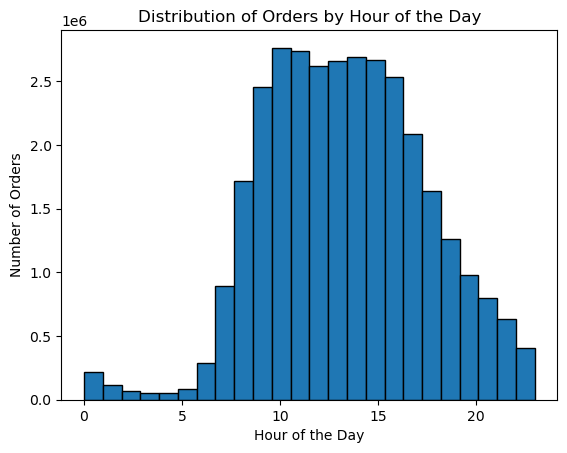

In [6]:
ords_cust['order_hour_of_day'].plot.hist(bins=24, edgecolor='black')

plt.title('Distribution of Orders by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Orders')
plt.show()

# Description:
The histogram shows the distribution of Instacart orders by hour of the day. Most orders occur between 10 a.m. and 4 p.m., with a noticeable peak around 10 a.m..
Activity drops sharply after 8 p.m. and remains very low during the early morning hours (midnight to 6 a.m.).
This indicates that Instacart customers tend to shop mainly during daytime hours, particularly late morning and early afternoon, likely when people are planning meals or have free time during the day.

In [7]:
# Exporting png

plt.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'order_hour_of_day_hist.png'))

plt.show()

<Figure size 640x480 with 0 Axes>

# Loyalty bar chart

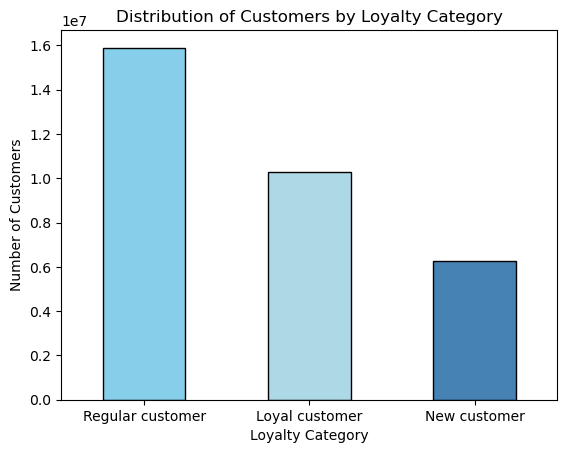

In [14]:
ords_cust['loyalty_flag'].value_counts().plot.bar(color=['skyblue', 'lightblue', 'steelblue'], edgecolor='black')

plt.title('Distribution of Customers by Loyalty Category')
plt.xlabel('Loyalty Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

# Comment
Most customers are regular, followed by loyal customers, while new customers make up the smallest group.
This suggests that Instacart has a solid base of repeat users and consistent customer engagement, but there’s still potential to grow the new customer segment.

In [18]:
# Export
plt.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'bar_loyalty_flag.png'))
plt.show()

<Figure size 640x480 with 0 Axes>

# Do customers spend differently depending on the time of day?

In [15]:
# Create a sample of the dataset

df = ords_cust[:2000000]

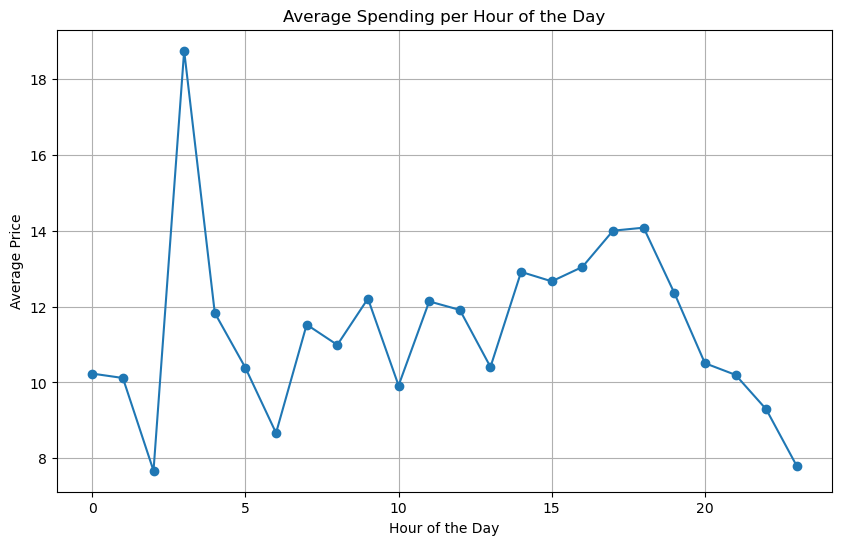

In [16]:
# Line chart of mean prices by hour of day
line = df.groupby('order_hour_of_day')['prices'].mean().plot.line(figsize=(10,6), marker='o')

plt.title('Average Spending per Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Price')
plt.grid(True)
plt.show()

# Comment
Overall, spending levels are relatively stable, with a noticeable spike around 4 a.m., which might be caused by a few outlier orders rather than a real behavioral pattern.
From morning to evening, spending remains fairly consistent, with a slight increase in the afternoon and early evening hours (14:00–18:00), suggesting that customers tend to place larger or higher-value orders during those times

# Export

In [19]:
plt.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'line_prices_by_hour.png'))
plt.show()

<Figure size 640x480 with 0 Axes>

# Determine whether there’s a connection between age and family situation

In [22]:
import pandas as pd
import os

path = r'/Users/mariatirado/Downloads/07-2024 Instacart Basket Analysis/02 Data/Original Data'
customers = pd.read_csv(os.path.join(path, 'customers.csv'))

In [25]:
customers.head()

,user_id,First Name,Surnam,Gender,STATE,Age,date_joined,n_dependants,fam_status,income
0,26711,Deborah,Esquivel,Female,Missouri,48,1/1/2017,3,married,165665
1,33890,Patricia,Hart,Female,New Mexico,36,1/1/2017,0,single,59285
2,65803,Kenneth,Farley,Male,Idaho,35,1/1/2017,2,married,99568
3,125935,Michelle,Hicks,Female,Iowa,40,1/1/2017,0,single,42049
4,130797,Ann,Gilmore,Female,Maryland,26,1/1/2017,1,married,40374


/var/folders/zj/m82l3gps79nc61v2flg2kkzr0000gn/T/ipykernel_13978/3576264768.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=customers, x='Age', y='n_dependants', ci=None, marker='o')


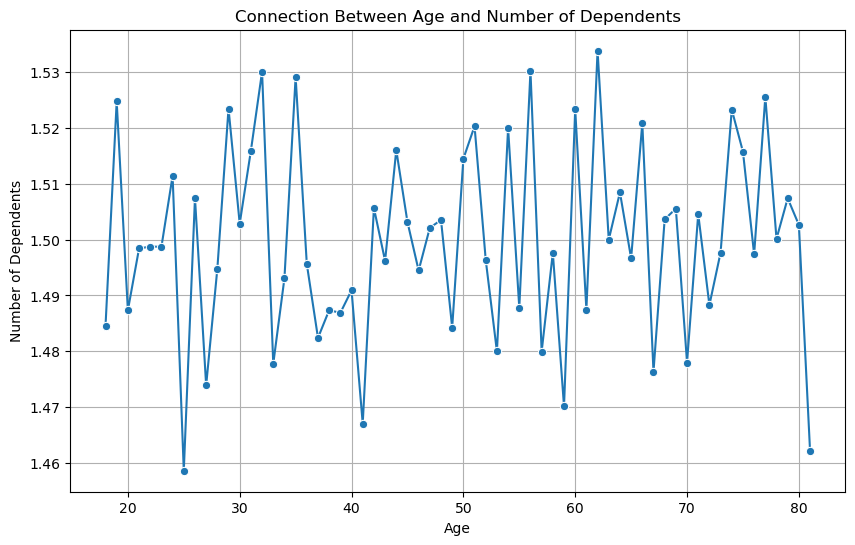

In [27]:
plt.figure(figsize=(10,6))
sns.lineplot(data=customers, x='Age', y='n_dependants', ci=None, marker='o')

plt.title('Connection Between Age and Number of Dependents')
plt.xlabel('Age')
plt.ylabel('Number of Dependents')
plt.grid(True)
plt.show()

# Comment
The line chart shows that there’s no clear relationship between age and number of dependents. Customers of different ages tend to have a similar number of dependents on average, suggesting that family size is relatively consistent across age groups in this dataset.

In [28]:
# Export 
path = r'/Users/mariatirado/29-10-2025 Instacart Basket Analysis'
plt.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'line_age_dependents.png'))
plt.show()

<Figure size 640x480 with 0 Axes>

# Explore whether there’s a connection between age and spending power (income)

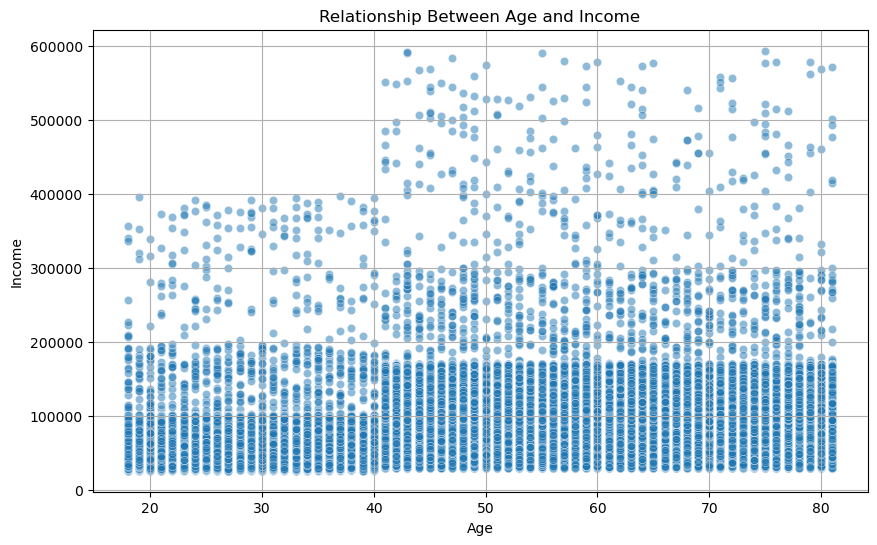

In [29]:
# Scatterplot: Age vs Income
plt.figure(figsize=(10,6))
sns.scatterplot(data=customers, x='Age', y='income', alpha=0.5)

plt.title('Relationship Between Age and Income')
plt.xlabel('Age')
plt.ylabel('Income')
plt.grid(True)
plt.show()

# Comment
There’s no strong linear correlation, incomes appear scattered across all ages.
However, there’s a slight tendency for higher incomes among older customers, while younger ones mostly cluster around lower income levels.
This means age might influence spending power a bit, but other factors (like occupation or household size) likely play a larger role.